Loading MNIST...
Data shape: (70000, 784)
Training GaussianNB...
Test accuracy: 0.5515714285714286

Learned parameters:
Means (theta_) shape : (10, 784)
Variance (var_) shape: (10, 784)

Generating synthetic digits...


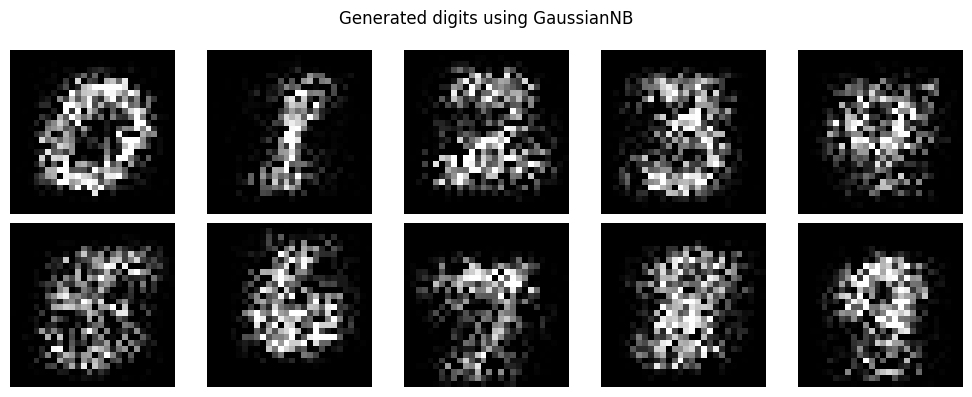


Done!


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

print("Loading MNIST...")
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

X = X.reshape(X.shape[0], -1)

X = X.astype(np.float32) / 255.0

print("Data shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Training GaussianNB...")

gnb = GaussianNB()
gnb.fit(X_train, y_train)

pred = gnb.predict(X_test)
acc = accuracy_score(y_test, pred)

print("Test accuracy:", acc)


print("\nLearned parameters:")
print("Means (theta_) shape :", gnb.theta_.shape)  # (10, 784)
print("Variance (var_) shape:", gnb.var_.shape)


def sample_from_class(model, class_label, n_samples=5):
    mean = model.theta_[class_label]
    var = model.var_[class_label]
    std = np.sqrt(var)

    samples = np.random.normal(mean, std, size=(n_samples, len(mean)))
    samples = np.clip(samples, 0, 1)

    return samples


def show_images(images, title="", ncols=5):
    n = len(images)
    nrows = int(np.ceil(n / ncols))

    plt.figure(figsize=(ncols * 2, nrows * 2))

    for i, img in enumerate(images):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


print("\nGenerating synthetic digits...")

all_images = []

for c in range(10):
    samples = sample_from_class(gnb, c, n_samples=1)
    all_images.extend(samples)

show_images(all_images, title="Generated digits using GaussianNB", ncols=5)


print("\nDone!")
